In [1]:
checkpoint = "prajjwal1/bert-tiny"
tokenizer_checkpoint = "bert-base-uncased"
dataset_name = "imdb"

from chop.tools import get_tokenized_dataset

dataset, tokenizer = get_tokenized_dataset(
    dataset=dataset_name,
    checkpoint=tokenizer_checkpoint,
    return_tokenizer=True,
)

/home/alex/Documents/yr_4/ADLS/ELEC70109-Advanced-Deep-Learning-Systems/.venv/lib/python3.11/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/alex/Documents/yr_4/ADLS/ELEC70109-Advanced-Deep-Learning-Systems/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO     Tokenizing dataset imdb with AutoTokenizer for bert-base-uncased.


In [ ]:
import torch.nn as nn
from chop.nn.modules import Identity

search_space = {
    "num_layers": [2, 4, 8],
    "num_heads": [2, 4, 8, 16],
    "hidden_size": [128, 192, 256, 384, 512],
    "intermediate_size": [512, 768, 1024, 1536, 2048],
    "linear_layer_choices": [
        nn.Linear,
        Identity,
    ],
}

from transformers import AutoConfig, AutoModelForSequenceClassification
from chop.tools.utils import deepsetattr


def construct_model(trial):
    config = AutoConfig.from_pretrained(checkpoint)

    # Update the paramaters in the config
    for param in [
        "num_layers",
        "num_heads",
        "hidden_size",
        "intermediate_size",
    ]:
        chosen_idx = trial.suggest_int(param, 0, len(search_space[param]) - 1)
        setattr(config, param, search_space[param][chosen_idx])

    trial_model = AutoModelForSequenceClassification.from_config(config)

    for name, layer in trial_model.named_modules():
        if isinstance(layer, nn.Linear) and layer.in_features == layer.out_features:
            new_layer_cls = trial.suggest_categorical(
                f"{name}_type",
                search_space["linear_layer_choices"],
            )

            if new_layer_cls == nn.Linear:
                continue
            elif new_layer_cls == Identity:
                new_layer = Identity()
                deepsetattr(trial_model, name, new_layer)
            else:
                raise ValueError(f"Unknown layer type: {new_layer_cls}")

    return trial_model

In [ ]:
def grid_construct_model(trial):
    config = AutoConfig.from_pretrained(checkpoint)

    for param in [
        "num_layers",
        "num_heads",
        "hidden_size",
        "intermediate_size",
    ]:
        param_value = trial.suggest_categorical(param, search_space[param])
        setattr(config, param, param_value)

    trial_model = AutoModelForSequenceClassification.from_config(config)

  
    for name, layer in trial_model.named_modules():
        if isinstance(layer, nn.Linear) and layer.in_features == layer.out_features:
            new_layer_cls = trial.suggest_categorical(
                "linear_layer_choices",
                search_space["linear_layer_choices"],
            )

            if new_layer_cls == nn.Linear:
                continue
            elif new_layer_cls == Identity:
                new_layer = Identity()
                deepsetattr(trial_model, name, new_layer)
            else:
                raise ValueError(f"Unknown layer type: {new_layer_cls}")
    

    return trial_model

def grid_objective(trial):
    model = grid_construct_model(trial)

    trainer = get_trainer(
        model=model,
        tokenized_dataset=dataset,
        tokenizer=tokenizer,
        evaluate_metric="accuracy",
        num_train_epochs=1,
    )

    trainer.train()
    eval_results = trainer.evaluate()

    trial.set_user_attr("model", model)

    return eval_results["eval_accuracy"]

: 

In [ ]:
from chop.tools import get_trainer


def objective(trial):

    # Define the model
    model = construct_model(trial)

    trainer = get_trainer(
        model=model,
        tokenized_dataset=dataset,
        tokenizer=tokenizer,
        evaluate_metric="accuracy",
        num_train_epochs=1,
    )

    trainer.train()
    eval_results = trainer.evaluate()

    # Set the model as an attribute so we can fetch it later
    trial.set_user_attr("model", model)

    return eval_results["eval_accuracy"]

# Part 1 compression unaware search

In [4]:
from optuna.samplers import GridSampler, RandomSampler, TPESampler

In [ ]:
import optuna

n_trials = 50

random_sampler_study = optuna.create_study(
    direction="maximize",
    study_name="bert-tiny-nas-study",
    sampler=RandomSampler(),
)


random_sampler_study.optimize(
    objective,
    n_trials=n_trials,
    timeout=60 * 60 * 24,
)

grid_sampler_study = optuna.create_study(
    direction="maximize",
    study_name="bert-tiny-nas-grid-study",
    sampler=GridSampler(search_space),
)
grid_sampler_study.optimize(
    grid_objective,
    n_trials=n_trials,
    timeout=60 * 60 * 24,
)

tpe_sampler_study = optuna.create_study(
    direction="maximize",
    study_name="bert-tiny-nas-tpe-study",
    sampler=TPESampler(),
)
tpe_sampler_study.optimize(
    objective,
    n_trials=n_trials,
    timeout=60 * 60 * 24,
)

# print the array of accuracies for each study
print("Random Sampler Accuracies:", [trial.value for trial in random_sampler_study
    .trials])
print("Grid Sampler Accuracies:", [trial.value for trial in grid_sampler_study
    .trials])
print("TPE Sampler Accuracies:", [trial.value for trial in tpe_sampler_study
    .trials])


[I 2026-02-06 13:00:49,270] A new study created in memory with name: bert-tiny-nas-study
/home/alex/Documents/yr_4/ADLS/ELEC70109-Advanced-Deep-Learning-Systems/.venv/lib/python3.11/site-packages/optuna/distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains <class 'torch.nn.modules.linear.Linear'> which is of type type.
  warnings.warn(message)
/home/alex/Documents/yr_4/ADLS/ELEC70109-Advanced-Deep-Learning-Systems/.venv/lib/python3.11/site-packages/optuna/distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains <class 'chop.nn.modules.identity.Identity'> which is of type type.
  warnings.warn(message)
/home/alex/Documents/yr_4/ADLS/ELEC70109-Advanced-Deep-Learning-Systems/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version

Step,Training Loss
500,0.683100
1000,0.498300
1500,0.407200
2000,0.373800
2500,0.340000
3000,0.347000


[I 2026-02-06 13:02:43,182] Trial 0 finished with value: 0.86236 and parameters: {'num_layers': 2, 'num_heads': 2, 'hidden_size': 2, 'intermediate_size': 2, 'linear_layer_choices': <class 'torch.nn.modules.linear.Linear'>}. Best is trial 0 with value: 0.86236.
'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 8648836d-d30a-49d8-9573-591a8656b544)')' thrown while requesting HEAD https://huggingface.co/prajjwal1/bert-tiny/resolve/main/config.json
Retrying in 1s [Retry 1/5].
'(MaxRetryError('HTTPSConnectionPool(host=\'huggingface.co\', port=443): Max retries exceeded with url: /prajjwal1/bert-tiny/resolve/main/config.json (Caused by NewConnectionError("HTTPSConnection(host=\'huggingface.co\', port=443): Failed to establish a new connection: [Errno 16] Device or resource busy"))'), '(Request ID: 19fb8739-d29e-45c3-832e-fc986212c789)')' thrown while requesting HEAD https://huggingface.co/prajjwal1/bert-tiny/resolve/m

Step,Training Loss
500,0.692500
1000,0.674800
1500,0.581200
2000,0.497800
2500,0.458500
3000,0.450200


[I 2026-02-06 13:04:34,159] Trial 1 finished with value: 0.81288 and parameters: {'num_layers': 2, 'num_heads': 2, 'hidden_size': 0, 'intermediate_size': 3, 'linear_layer_choices': <class 'chop.nn.modules.identity.Identity'>}. Best is trial 0 with value: 0.86236.
'(MaxRetryError('HTTPSConnectionPool(host=\'huggingface.co\', port=443): Max retries exceeded with url: /prajjwal1/bert-tiny/resolve/main/config.json (Caused by NewConnectionError("HTTPSConnection(host=\'huggingface.co\', port=443): Failed to establish a new connection: [Errno 16] Device or resource busy"))'), '(Request ID: 5b235370-9f3e-44bc-a55a-c846796f79b4)')' thrown while requesting HEAD https://huggingface.co/prajjwal1/bert-tiny/resolve/main/config.json
Retrying in 1s [Retry 1/5].
'(MaxRetryError('HTTPSConnectionPool(host=\'huggingface.co\', port=443): Max retries exceeded with url: /prajjwal1/bert-tiny/resolve/main/config.json (Caused by NewConnectionError("HTTPSConnection(host=\'huggingface.co\', port=443): Failed to e

...

Step,Training Loss
500,0.659700
1000,0.485300
1500,0.397000
2000,0.362400
2500,0.324400
3000,0.336500


[I 2026-02-06 16:26:47,142] Trial 23 finished with value: 0.86812 and parameters: {'num_layers': 2, 'num_heads': 0, 'hidden_size': 3, 'intermediate_size': 3, 'linear_layer_choices': <class 'torch.nn.modules.linear.Linear'>}. Best is trial 12 with value: 0.86844.
'(MaxRetryError('HTTPSConnectionPool(host=\'huggingface.co\', port=443): Max retries exceeded with url: /prajjwal1/bert-tiny/resolve/main/config.json (Caused by NewConnectionError("HTTPSConnection(host=\'huggingface.co\', port=443): Failed to establish a new connection: [Errno 16] Device or resource busy"))'), '(Request ID: 97393e22-bbf9-4fe6-988c-a4c3eafe2441)')' thrown while requesting HEAD https://huggingface.co/prajjwal1/bert-tiny/resolve/main/config.json
Retrying in 1s [Retry 1/5].
'(MaxRetryError('HTTPSConnectionPool(host=\'huggingface.co\', port=443): Max retries exceeded with url: /prajjwal1/bert-tiny/resolve/main/config.json (Caused by NewConnectionError("HTTPSConnection(host=\'huggingface.co\', port=443): Failed to es

Step,Training Loss
500,0.659200
1000,0.508000
1500,0.434800
2000,0.382500
2500,0.334600
3000,0.355600


[I 2026-02-06 16:31:54,359] Trial 24 finished with value: 0.86844 and parameters: {'num_layers': 2, 'num_heads': 1, 'hidden_size': 4, 'intermediate_size': 4, 'linear_layer_choices': <class 'torch.nn.modules.linear.Linear'>}. Best is trial 12 with value: 0.86844.


Random Sampler Accuracies: [0.86236, 0.81288, 0.84916, 0.82664, 0.84916, 0.8384, 0.8252, 0.83452, 0.8384, 0.8252, 0.86112, 0.82744, 0.8646, 0.84244, 0.8026, 0.86172, 0.86112, 0.8566, 0.8148, 0.84048, 0.8214, 0.83128, 0.8148, 0.83452, 0.82664]
Grid Sampler Accuracies: [0.86812, 0.8548, 0.85564, 0.83128, 0.83148, 0.76792, 0.86812, 0.62492, 0.86812, 0.81476, 0.85664, 0.7616, 0.85876, 0.82664, 0.84244, 0.86112, 0.86552, 0.81288, 0.8148, 0.8614, 0.62492, 0.86552, 0.8576, 0.85624, 0.83128]
TPE Sampler Accuracies: [0.80476, 0.7616, 0.86552, 0.8148, 0.8548, 0.86172, 0.72712, 0.82268, 0.80416, 0.86332, 0.86112, 0.86332, 0.86844, 0.86844, 0.86112, 0.85664, 0.85664, 0.8664, 0.86112, 0.86844, 0.84048, 0.86844, 0.86844, 0.86812, 0.86844]


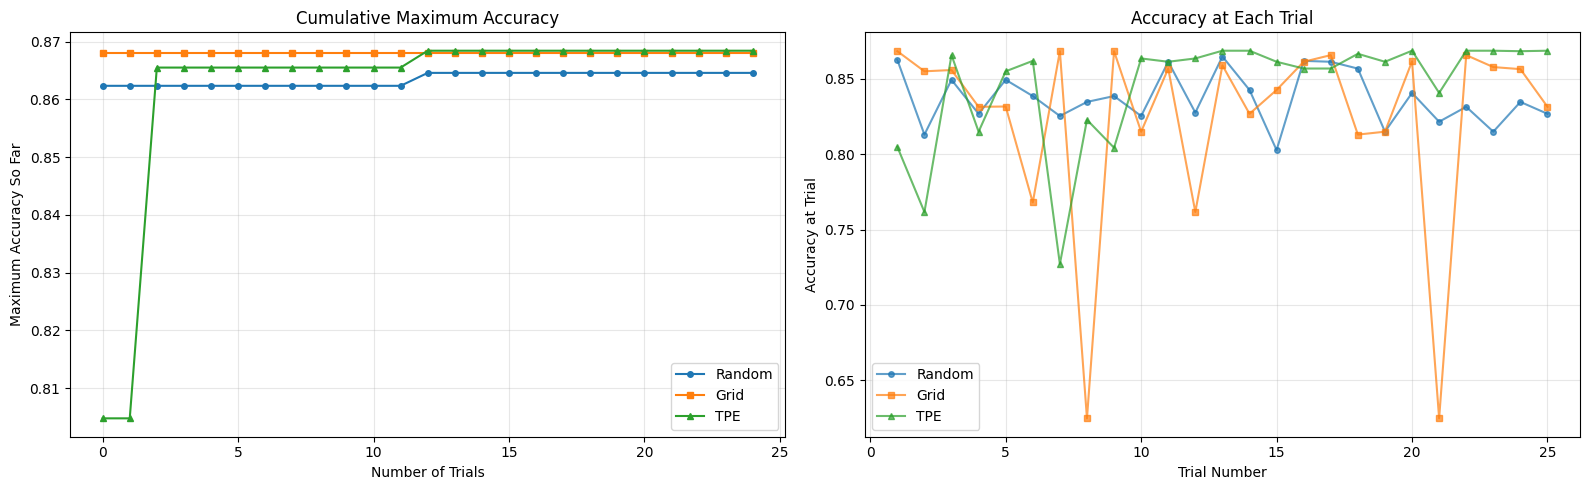

Random Sampler - Final accuracies: [0.86236, 0.81288, 0.84916, 0.82664, 0.84916, 0.8384, 0.8252, 0.83452, 0.8384, 0.8252, 0.86112, 0.82744, 0.8646, 0.84244, 0.8026, 0.86172, 0.86112, 0.8566, 0.8148, 0.84048, 0.8214, 0.83128, 0.8148, 0.83452, 0.82664]
Grid Sampler - Final accuracies: [0.86812, 0.8548, 0.85564, 0.83128, 0.83148, 0.76792, 0.86812, 0.62492, 0.86812, 0.81476, 0.85664, 0.7616, 0.85876, 0.82664, 0.84244, 0.86112, 0.86552, 0.81288, 0.8148, 0.8614, 0.62492, 0.86552, 0.8576, 0.85624, 0.83128]
TPE Sampler - Final accuracies: [0.80476, 0.7616, 0.86552, 0.8148, 0.8548, 0.86172, 0.72712, 0.82268, 0.80416, 0.86332, 0.86112, 0.86332, 0.86844, 0.86844, 0.86112, 0.85664, 0.85664, 0.8664, 0.86112, 0.86844, 0.84048, 0.86844, 0.86844, 0.86812, 0.86844]

Random Sampler - Best accuracy: 0.8646
Grid Sampler - Best accuracy: 0.86812
TPE Sampler - Best accuracy: 0.86844


In [40]:
import matplotlib.pyplot as plt
import numpy as np

def cummax(acc_list):
    max_so_far = acc_list[0]
    result = []
    for acc in acc_list:
        if acc > max_so_far:
            max_so_far = acc
        result.append(max_so_far)
    return result

# Get the trial accuracies
random_accs = [t.value for t in random_sampler_study.trials]
grid_accs = [t.value for t in grid_sampler_study.trials]
tpe_accs = [t.value for t in tpe_sampler_study.trials]

# Create figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Best accuracy so far (cumulative max)
ax1.plot(cummax(random_accs), label='Random', marker='o', markersize=4)
ax1.plot(cummax(grid_accs), label='Grid', marker='s', markersize=4)
ax1.plot(cummax(tpe_accs), label='TPE', marker='^', markersize=4)

ax1.set_xlabel('Number of Trials')
ax1.set_ylabel('Maximum Accuracy So Far')
ax1.set_title('Cumulative Maximum Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Accuracy at each trial
trial_numbers = list(range(1, len(random_accs) + 1))
ax2.plot(trial_numbers, random_accs, label='Random', marker='o', markersize=4, alpha=0.7)
ax2.plot(trial_numbers, grid_accs, label='Grid', marker='s', markersize=4, alpha=0.7)
ax2.plot(trial_numbers, tpe_accs, label='TPE', marker='^', markersize=4, alpha=0.7)

ax2.set_xlabel('Trial Number')
ax2.set_ylabel('Accuracy at Trial')
ax2.set_title('Accuracy at Each Trial')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Also print some statistics
print("Random Sampler - Final accuracies:", random_accs)
print("Grid Sampler - Final accuracies:", grid_accs)
print("TPE Sampler - Final accuracies:", tpe_accs)
print()
print("Random Sampler - Best accuracy:", max(random_accs) if random_accs else "N/A")
print("Grid Sampler - Best accuracy:", max(grid_accs) if grid_accs else "N/A")
print("TPE Sampler - Best accuracy:", max(tpe_accs) if tpe_accs else "N/A")

In [67]:
from xml.parsers.expat import model
from chop.tools import get_trainer
import chop.passes as passes
from chop import MaseGraph



def quantization_aware_objective(trial):

    quantization_config = {
        "by": "type",
        "default": {
            "config": {
                "name": None,
            }
        },
        "linear": {
            "config": {
                "name": "integer",
                # data
                "data_in_width": 8,
                "data_in_frac_width": 4,
                # weight
                "weight_width": 8,
                "weight_frac_width": 4,
                # bias
                "bias_width": 8,
                "bias_frac_width": 4,
            }
        },
    }

    pruning_config = {
        "weight": {
            "sparsity": 0.7,
            "method": "l1-norm",
            "scope": "local",
        },
        "activation": {
            "sparsity": 0.7,
            "method": "l1-norm",
            "scope": "local",
        },
    }

    # Define the model
    model = construct_model(trial)
    model.config.problem_type = "single_label_classification"

    mg = MaseGraph(
        model,
        hf_input_names=[
            "input_ids",
            "attention_mask",
            "labels",
        ],
    )

    mg, _ = passes.init_metadata_analysis_pass(mg)
    mg, _ = passes.add_common_metadata_analysis_pass(mg)

    trainer = get_trainer(
        model=mg.model,
        tokenized_dataset=dataset,
        tokenizer=tokenizer,
        evaluate_metric="accuracy",
        num_train_epochs=3,
    )

    trainer.train()
    eval_results = trainer.evaluate()

    # Set the model as an attribute so we can fetch it later
    trial.set_user_attr("base model", model)
    trial.set_user_attr("pre_quantization_accuracy", eval_results["eval_accuracy"])
    print(f"base accuracy: {eval_results['eval_accuracy']}")

    
    print("quantization config:", quantization_config)
    mg, _ = passes.quantize_transform_pass(mg,pass_args=quantization_config)
    mg.model.to("cuda:0")
    mg, _ = passes.prune_transform_pass(mg, pass_args=pruning_config)
    mg.model.to("cuda:0")
    print("quantization complete")
    trainer = get_trainer(
        model=mg.model,
        tokenized_dataset=dataset,
        tokenizer=tokenizer,
        evaluate_metric="accuracy",
        num_train_epochs=1,
    )
    # Evaluate accuracy
    eval_results = trainer.evaluate()
    print(f"after comperession accuracy: {eval_results['eval_accuracy']}")
    trial.set_user_attr("after compression", eval_results["eval_accuracy"])

    trainer.train()
    eval_results = trainer.evaluate()
    print(f"PQT accuracy: {eval_results['eval_accuracy']}")
    trial.set_user_attr("pqt", eval_results["eval_accuracy"])

    return eval_results["eval_accuracy"]

tpe_sampler_study = optuna.create_study(
    direction="maximize",
    study_name="bert-tiny-nas-tpe-study",
    sampler=TPESampler(),
)
tpe_sampler_study.optimize(
    quantization_aware_objective,
    n_trials=15,
    timeout=60 * 60 * 24,
)

[I 2026-02-07 17:06:12,569] A new study created in memory with name: bert-tiny-nas-tpe-study
/home/alex/Documents/yr_4/ADLS/ELEC70109-Advanced-Deep-Learning-Systems/.venv/lib/python3.11/site-packages/optuna/distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains <class 'torch.nn.modules.linear.Linear'> which is of type type.
  warnings.warn(message)
/home/alex/Documents/yr_4/ADLS/ELEC70109-Advanced-Deep-Learning-Systems/.venv/lib/python3.11/site-packages/optuna/distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains <class 'chop.nn.modules.identity.Identity'> which is of type type.
  warnings.warn(message)
`past_key_values` were not specified as input names, but model.config.use_cache = True. Setting model.config.use_cache = False.
INFO     Getting dummy input for prajjwal1/ber

tensor([[ 101, 9932, 2089, 2202, 2058, 1996, 2088, 2028, 2154,  102],
        [ 101, 2023, 2003, 2339, 2017, 2323, 4553, 4748, 4877,  102]])
tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])
tensor([[ 101, 9932, 2089, 2202, 2058, 1996, 2088, 2028, 2154,  102],
        [ 101, 2023, 2003, 2339, 2017, 2323, 4553, 4748, 4877,  102]])
tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])
tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])
tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])
tensor([[[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]],


        [[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]]])
tensor([[[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       

/home/alex/Documents/yr_4/ADLS/ELEC70109-Advanced-Deep-Learning-Systems/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
500,0.672000
1000,0.503700
1500,0.399200
2000,0.365300
2500,0.346400
3000,0.370400
3500,0.312200
4000,0.283600
4500,0.284700
5000,0.303700


INFO     Pruning module: bert_encoder_layer_0_attention_self_query
INFO     Pruning module: bert_encoder_layer_0_attention_self_key
INFO     Pruning module: bert_encoder_layer_0_attention_self_value
INFO     Pruning module: bert_encoder_layer_0_attention_output_dense
INFO     Pruning module: bert_encoder_layer_0_intermediate_dense
INFO     Pruning module: bert_encoder_layer_0_output_dense
INFO     Pruning module: bert_encoder_layer_1_attention_self_query
INFO     Pruning module: bert_encoder_layer_1_attention_self_key
INFO     Pruning module: bert_encoder_layer_1_attention_self_value
INFO     Pruning module: bert_encoder_layer_1_attention_output_dense
INFO     Pruning module: bert_encoder_layer_1_intermediate_dense
INFO     Pruning module: bert_encoder_layer_1_output_dense
INFO     Pruning module: bert_pooler_dense
INFO     Pruning module: classifier


...

/home/alex/Documents/yr_4/ADLS/ELEC70109-Advanced-Deep-Learning-Systems/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


after comperession accuracy: 0.52272


Step,Training Loss
500,0.384700
1000,0.299200
1500,0.302800
2000,0.275100
2500,0.247800
3000,0.276600


[I 2026-02-07 19:53:29,717] Trial 14 finished with value: 0.8648 and parameters: {'num_layers': 0, 'num_heads': 1, 'hidden_size': 1, 'intermediate_size': 1, 'linear_layer_choices': <class 'chop.nn.modules.identity.Identity'>}. Best is trial 13 with value: 0.87148.


PQT accuracy: 0.8648


ANALYZING TPE SAMPLER RESULTS
Found 15 completed trials

Trial-by-trial results:
--------------------------------------------------------------------------------
Trial  Base Acc     After Comp   PQT Acc     
--------------------------------------------------------------------------------
1      0.8761 (87.61%)  0.5298 (52.98%)  0.8400 (84.00%)
2      0.8789 (87.89%)  0.7726 (77.26%)  0.8656 (86.56%)
3      0.8778 (87.78%)  0.8436 (84.36%)  0.8619 (86.19%)
4      0.8695 (86.95%)  0.6057 (60.57%)  0.8672 (86.72%)
5      0.8706 (87.06%)  0.6822 (68.22%)  0.8696 (86.96%)
6      0.8779 (87.79%)  0.6200 (62.00%)  0.8603 (86.03%)
7      0.8785 (87.85%)  0.5445 (54.45%)  0.8320 (83.20%)
8      0.8756 (87.56%)  0.6318 (63.18%)  0.8304 (83.04%)
9      0.8674 (86.74%)  0.6982 (69.82%)  0.8674 (86.74%)
10     0.8726 (87.26%)  0.6130 (61.30%)  0.8688 (86.88%)
11     0.8750 (87.50%)  0.6110 (61.10%)  0.8660 (86.60%)
12     0.8733 (87.33%)  0.5737 (57.37%)  0.8658 (86.58%)
13     0.8732 (87.32%)  0.7

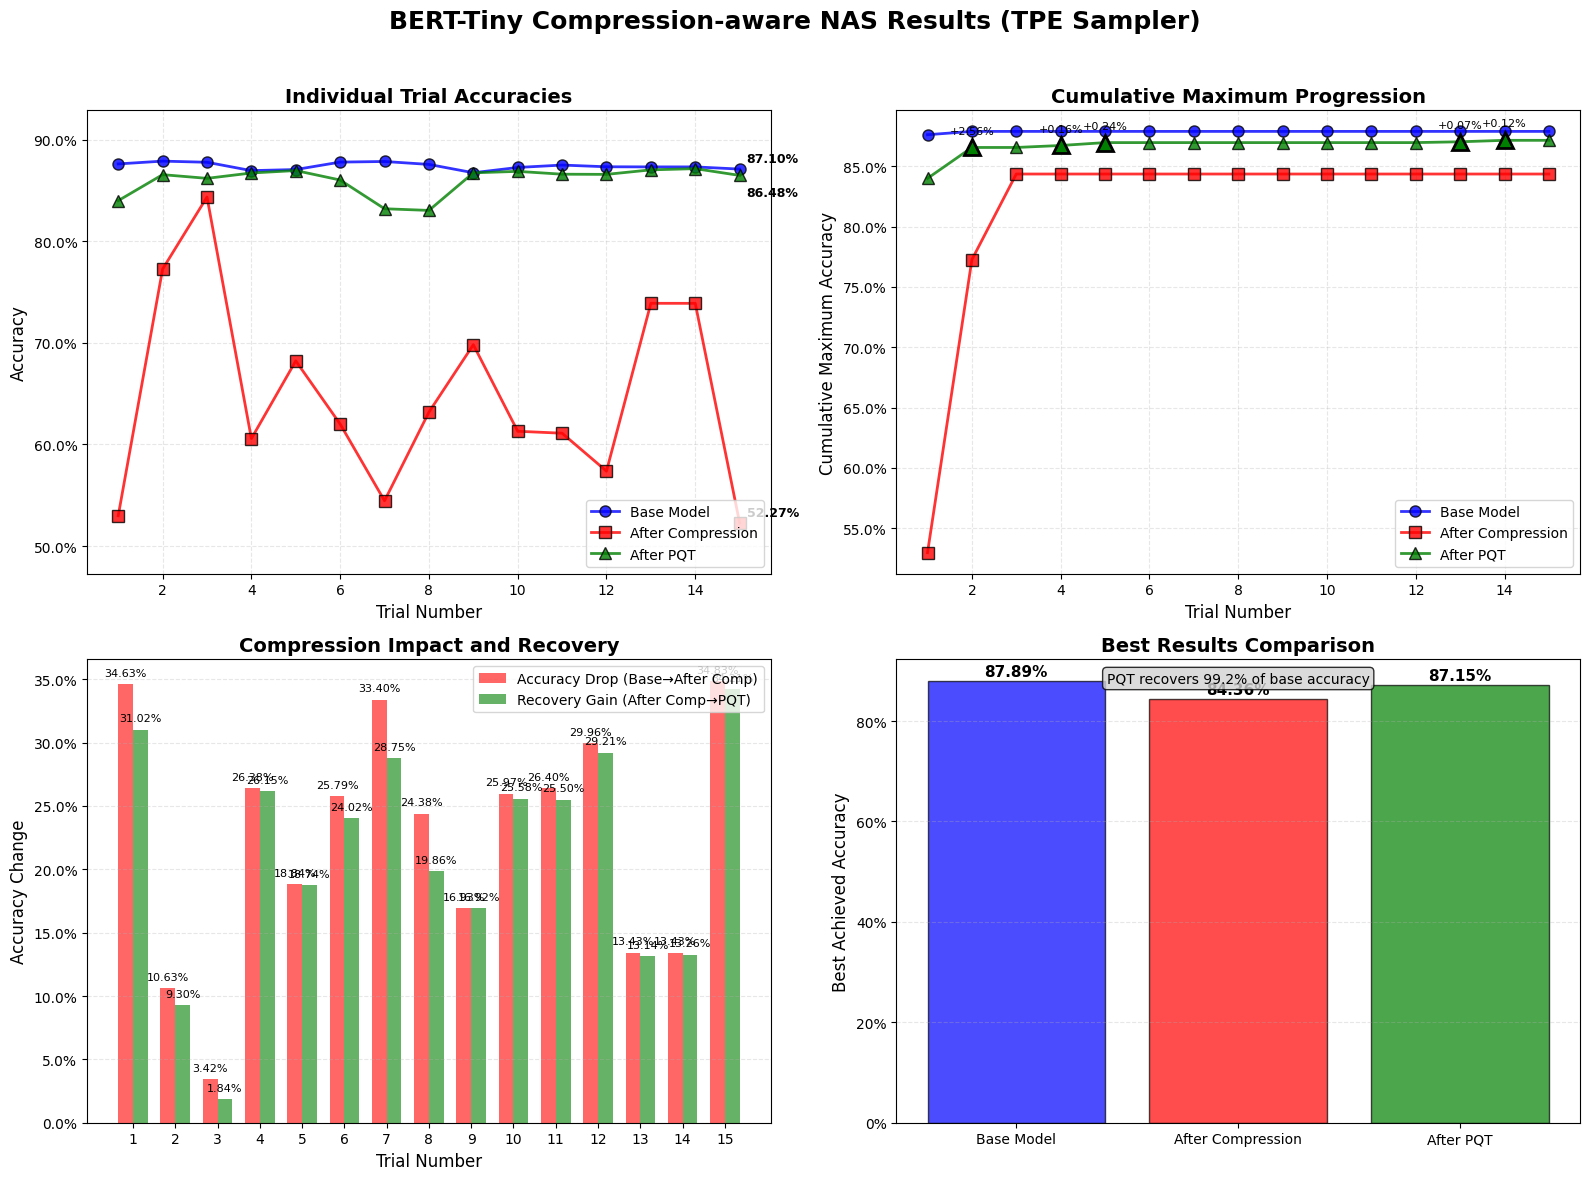

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import PercentFormatter

print("="*80)
print("ANALYZING TPE SAMPLER RESULTS")
print("="*80)

# Extract data from your completed study
completed_trials = [t for t in tpe_sampler_study.trials if t.state.name == "COMPLETE"]
print(f"Found {len(completed_trials)} completed trials")

if len(completed_trials) == 0:
    print("No completed trials found!")
else:
    # Extract metrics from each trial
    trial_numbers = []
    base_accuracies = []
    after_comp_accuracies = []
    pqt_accuracies = []
    
    print("\nTrial-by-trial results:")
    print("-"*80)
    print(f"{'Trial':<6} {'Base Acc':<12} {'After Comp':<12} {'PQT Acc':<12}")
    print("-"*80)
    
    for i, trial in enumerate(completed_trials):
        trial_numbers.append(i + 1)
        base_acc = trial.user_attrs.get("pre_quantization_accuracy", 0)
        after_comp = trial.user_attrs.get("after compression", 0)
        pqt_acc = trial.user_attrs.get("pqt", 0)
        
        base_accuracies.append(base_acc)
        after_comp_accuracies.append(after_comp)
        pqt_accuracies.append(pqt_acc)
        
        print(f"{i+1:<6} {base_acc:.4f} ({base_acc:.2%})  "
              f"{after_comp:.4f} ({after_comp:.2%})  "
              f"{pqt_acc:.4f} ({pqt_acc:.2%})")

    print("-"*80)
    
    # Calculate cumulative maximum for each curve
    def cumulative_max(values):
        cummax_vals = []
        current_max = -float('inf')
        for val in values:
            current_max = max(current_max, val)
            cummax_vals.append(current_max)
        return cummax_vals
    
    base_cummax = cumulative_max(base_accuracies)
    after_comp_cummax = cumulative_max(after_comp_accuracies)
    pqt_cummax = cumulative_max(pqt_accuracies)
    
    print("\nCumulative maximum values:")
    print("-"*80)
    print(f"{'Trial':<6} {'Base CumMax':<12} {'AfterComp CumMax':<12} {'PQT CumMax':<12}")
    print("-"*80)
    for i in range(len(trial_numbers)):
        print(f"{i+1:<6} {base_cummax[i]:.4f} ({base_cummax[i]:.2%})  "
              f"{after_comp_cummax[i]:.4f} ({after_comp_cummax[i]:.2%})  "
              f"{pqt_cummax[i]:.4f} ({pqt_cummax[i]:.2%})")
    
    print("="*80)
    
    # Create a 2x2 subplot figure
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    plt.suptitle('BERT-Tiny Compression-aware NAS Results (TPE Sampler)', 
                 fontsize=18, fontweight='bold', y=0.98)
    
    # PLOT 1: Individual trial accuracies (Top Left)
    ax1 = axes[0, 0]
    ax1.plot(trial_numbers, base_accuracies, 'b-o', linewidth=2, markersize=8,
             label='Base Model', alpha=0.8, markeredgecolor='black')
    ax1.plot(trial_numbers, after_comp_accuracies, 'r-s', linewidth=2, markersize=8,
             label='After Compression', alpha=0.8, markeredgecolor='black')
    ax1.plot(trial_numbers, pqt_accuracies, 'g-^', linewidth=2, markersize=8,
             label='After PQT', alpha=0.8, markeredgecolor='black')
    ax1.set_xlabel('Trial Number', fontsize=12)
    ax1.set_ylabel('Accuracy', fontsize=12)
    ax1.set_title('Individual Trial Accuracies', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3, linestyle='--')
    ax1.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax1.legend(loc='lower right')
    ax1.set_ylim([max(0, min(min(base_accuracies), min(after_comp_accuracies), min(pqt_accuracies)) - 0.05), 
                  min(1.0, max(max(base_accuracies), max(after_comp_accuracies), max(pqt_accuracies)) + 0.05)])
    
    # Add value labels for the last point
    if len(trial_numbers) > 0:
        ax1.annotate(f'{base_accuracies[-1]:.2%}', 
                    xy=(trial_numbers[-1], base_accuracies[-1]),
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=9, fontweight='bold')
        ax1.annotate(f'{after_comp_accuracies[-1]:.2%}', 
                    xy=(trial_numbers[-1], after_comp_accuracies[-1]),
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=9, fontweight='bold')
        ax1.annotate(f'{pqt_accuracies[-1]:.2%}', 
                    xy=(trial_numbers[-1], pqt_accuracies[-1]),
                    xytext=(5, -15), textcoords='offset points',
                    fontsize=9, fontweight='bold')
    
    # PLOT 2: Cumulative maximum (Top Right)
    ax2 = axes[0, 1]
    ax2.plot(trial_numbers, base_cummax, 'b-o', linewidth=2, markersize=8,
             label='Base Model', alpha=0.8, markeredgecolor='black')
    ax2.plot(trial_numbers, after_comp_cummax, 'r-s', linewidth=2, markersize=8,
             label='After Compression', alpha=0.8, markeredgecolor='black')
    ax2.plot(trial_numbers, pqt_cummax, 'g-^', linewidth=2, markersize=8,
             label='After PCT', alpha=0.8, markeredgecolor='black')
    ax2.set_xlabel('Trial Number', fontsize=12)
    ax2.set_ylabel('Cumulative Maximum Accuracy', fontsize=12)
    ax2.set_title('Cumulative Maximum Progression', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3, linestyle='--')
    ax2.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax2.legend(loc='lower right')
    
    # Highlight improvements on cummax plot
    for i in range(1, len(trial_numbers)):
        if pqt_cummax[i] > pqt_cummax[i-1]:
            ax2.plot(trial_numbers[i], pqt_cummax[i], 'g^', markersize=12, 
                    markeredgecolor='black', markeredgewidth=2)
            ax2.annotate(f'+{pqt_cummax[i]-pqt_cummax[i-1]:.2%}', 
                        xy=(trial_numbers[i], pqt_cummax[i]),
                        xytext=(0, 10), textcoords='offset points',
                        fontsize=8, ha='center')
    
    # PLOT 3: Accuracy drop after compression (Bottom Left)
    ax3 = axes[1, 0]
    compression_drop = [base - after for base, after in zip(base_accuracies, after_comp_accuracies)]
    recovery_gain = [pqt - after for pqt, after in zip(pqt_accuracies, after_comp_accuracies)]
    
    x = np.arange(len(trial_numbers))
    width = 0.35
    
    bars1 = ax3.bar(x - width/2, compression_drop, width, label='Accuracy Drop (Base→After Comp)', 
                    color='red', alpha=0.6)
    bars2 = ax3.bar(x + width/2, recovery_gain, width, label='Recovery Gain (After Comp→PQT)', 
                    color='green', alpha=0.6)
    
    ax3.set_xlabel('Trial Number', fontsize=12)
    ax3.set_ylabel('Accuracy Change', fontsize=12)
    ax3.set_title('Compression Impact and Recovery', fontsize=14, fontweight='bold')
    ax3.set_xticks(x)
    ax3.set_xticklabels(trial_numbers)
    ax3.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax3.grid(True, alpha=0.3, linestyle='--', axis='y')
    ax3.legend(loc='upper right')
    
    # Add value labels on bars
    for bar in bars1:
        height = bar.get_height()
        if height != 0:
            ax3.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                    f'{height:.2%}', ha='center', va='bottom', fontsize=8)
    
    for bar in bars2:
        height = bar.get_height()
        if height != 0:
            ax3.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                    f'{height:.2%}', ha='center', va='bottom', fontsize=8)
    
    # PLOT 4: Final comparison (Bottom Right)
    ax4 = axes[1, 1]
    categories = ['Base Model', 'After Compression', 'After PQT']
    final_values = [base_cummax[-1], after_comp_cummax[-1], pqt_cummax[-1]]
    colors = ['blue', 'red', 'green']
    
    bars = ax4.bar(categories, final_values, color=colors, alpha=0.7, edgecolor='black')
    ax4.set_ylabel('Best Achieved Accuracy', fontsize=12)
    ax4.set_title('Best Results Comparison', fontsize=14, fontweight='bold')
    ax4.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax4.grid(True, alpha=0.3, linestyle='--', axis='y')
    
    # Add value labels on bars
    for bar, val in zip(bars, final_values):
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                f'{val:.2%}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    # Calculate and display recovery percentage
    recovery_pct = (pqt_cummax[-1] / base_cummax[-1] * 100) if base_cummax[-1] > 0 else 0
    ax4.text(0.5, 0.95, f'PQT recovers {recovery_pct:.1f}% of base accuracy',
             transform=ax4.transAxes, ha='center', fontsize=10,
             bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))
    
    # Adjust layout
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    
    # Save the plot
    plt.savefig('bert_tiny_tpe_comprehensive_results.png', dpi=300, bbox_inches='tight')
    
    # Print final summary
    print("\n" + "="*80)
    print("FINAL SUMMARY")
    print("="*80)
    print(f"Best Base Model Accuracy: {base_cummax[-1]:.4f} ({base_cummax[-1]:.2%})")
    print(f"Best After Compression Accuracy: {after_comp_cummax[-1]:.4f} ({after_comp_cummax[-1]:.2%})")
    print(f"Best After PQT Accuracy: {pqt_cummax[-1]:.4f} ({pqt_cummax[-1]:.2%})")
    print(f"Average Compression Drop: {np.mean(compression_drop):.4f} ({np.mean(compression_drop):.2%})")
    print(f"Average Recovery Gain: {np.mean(recovery_gain):.4f} ({np.mean(recovery_gain):.2%})")
    print(f"Final PQT Recovery Rate: {recovery_pct:.1f}% of base accuracy")
    
    # Find best trial
    best_trial_idx = np.argmax(pqt_accuracies)
    print(f"\nBest Trial: #{best_trial_idx + 1}")
    print(f"  Base Accuracy: {base_accuracies[best_trial_idx]:.2%}")
    print(f"  After Compression: {after_comp_accuracies[best_trial_idx]:.2%}")
    print(f"  After PQT: {pqt_accuracies[best_trial_idx]:.2%}")
    print("="*80)
    
    # Show the plot
    plt.show()

In [ ]:
from pathlib import Path
import dill

model = study.best_trial.user_attrs["model"].cpu()

with open("../saves/tutorial_5_best_model.pkl", "wb") as f:
    dill.dump(model, f)

In [ ]:
mg.export("../saves/tutorial_5_nas_compressed", save_format="state_dict")